# Reinforcement Learning

## Taxi

from: https://www.gymlibrary.dev/environments/toy_text/taxi/

![taxi](https://www.gymlibrary.dev/_images/taxi.gif)


### Description

There are four designated locations in the grid world indicated by R(ed), G(reen), Y(ellow), and B(lue). When the episode starts, the taxi starts off at a random square and the passenger is at a random location. The taxi drives to the passenger’s location, picks up the passenger, drives to the passenger’s destination (another one of the four specified locations), and then drops off the passenger. Once the passenger is dropped off, the episode ends.


### Actions

There are 6 discrete deterministic actions:

    0: move south
    1: move north
    2: move east
    3: move west
    4: pickup passenger
    5: drop off passenger


### Observations

There are 500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations.

Note that there are 400 states that can actually be reached during an episode. The missing states correspond to situations in which the passenger is at the same location as their destination, as this typically signals the end of an episode. Four additional states can be observed right after a successful episodes, when both the passenger and the taxi are at the destination. This gives a total of 404 reachable discrete states.

Each state space is represented by the tuple: (taxi_row, taxi_col, passenger_location, destination)

An observation is an integer that encodes the corresponding state. The state tuple can then be decoded with the “decode” method.

Passenger locations:

    0: R(ed)
    1: G(reen)
    2: Y(ellow)
    3: B(lue)
    4: in taxi

Destinations:

    0: R(ed)
    1: G(reen)
    2: Y(ellow)
    3: B(lue)


### Rewards

    -1 per step unless other reward is triggered.
    +20 delivering passenger.
    -10 executing “pickup” and “drop-off” actions illegally.


### Install dependencies if needed
The following command will allow you to install gym, which is a toolkit for developing and comparing reinforcement learning algorithms: https://gym.openai.com/


pip install --upgrade git+https://github.com/openai/gym

### Import packages

In [1]:
import gym
from IPython.display import clear_output
from time import sleep
import numpy as np
from matplotlib import pyplot as pl

In [2]:
env = gym.make('Taxi-v3', render_mode='ansi').env

In [3]:
def print_frames(frames):
    for i, frame in enumerate(frames):
        clear_output(wait=True)
        print(frame['frame'])
        print(f'Timestep: {i + 1}')
        print(f"State: {frame['state']}")
        print(f"Action: {frame['action']}")
        print(f"Reward: {frame['reward']}")
        sleep(.1)

def argmax_choice(b):
    return np.random.choice(np.flatnonzero(b == b.max()))


# Brute force

First, let's test how much time it takes to an agent performing random actions to complete the task

In [4]:
env.reset()

epochs = 0
penalties, reward = 0, 0

frames = [] # for animation

done = False

while not done:
    action = env.action_space.sample()
    state, reward, done, _, _ = env.step(action)

    if reward == -10:
        penalties += 1
    
    # Put each rendered frame into dict for animation
    frames.append({
        'frame': env.render(),
        'state': state,
        'action': action,
        'reward': reward
        }
    )

    epochs += 1
    
print('Timesteps taken: {}'.format(epochs))
print('Penalties incurred: {}'.format(penalties))

        
print_frames(frames)


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B:_|
+---------+
  (South)

Timestep: 502
State: 498
Action: 0
Reward: -1


KeyboardInterrupt: 

# Q-learning
Now, let's use reinforcemet learning to solve the task

In [5]:
actions_dict = {0:'south',
                1:'north',
                2:'east',
                3:'west',
                4:'pickup',
                5:'dropoff'}

In [6]:
q_table = np.zeros([env.observation_space.n, env.action_space.n])

q_table.shape

(500, 6)

## Visualizing the Q table before learning

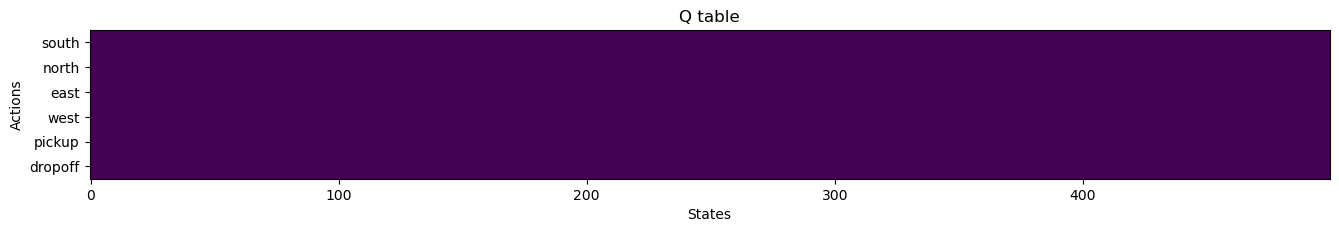

In [7]:
def show_q_table(table, binary=False):
    pl.figure(figsize=(16,4))
    
    if binary:
        temp = np.zeros(table.shape)
        for i,j in enumerate(np.argmax(table, axis=1)):
            temp[i,j] = 1
        pl.imshow(temp.T, interpolation='nearest', aspect=10)
    else:
        pl.imshow(table.T, interpolation='nearest', aspect=10)
    
    pl.yticks(range(len(actions_dict)), [actions_dict[k] for k in range(len(actions_dict))])
    pl.title('Q table')
    pl.xlabel('States')
    pl.ylabel('Actions')

show_q_table(q_table)

In [8]:
%%time

import matplotlib.pyplot as plt

print('Training the agent')

# Hyperparameters
DEFAULT_ALPHA = 0.1
DEFAULT_GAMMA = 0.6
DEFAULT_EPSILON = 0.1

N_EPOCHS = 20000
MEASURE_FREQUENCY = 100
N_EPISODES = 100
MAX_EPOCHS_IN_EPISODE = 100

scores = []

def choose_next_action(q_table, state, epsilon):
    if np.random.uniform(0, 1) < epsilon:
        return env.action_space.sample() # Explore action space
    return argmax_choice(q_table[state,:]) # Exploit learned values

def step_once(q_table, state, epsilon, alpha, gamma, learning):
    action = choose_next_action(q_table, state, epsilon)
    next_state, reward, done, _, _ = env.step(action)
    
    if learning:
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state,:])
        
        new_value = ((1 - alpha) * old_value) + (alpha * (reward + gamma * next_max))
        q_table[state, action] = new_value

    return q_table, next_state, reward, done

def test_hyperparams(alpha, gamma, epsilon):
    plot_data = []

    q_table = np.zeros([env.observation_space.n, env.action_space.n])
    
    for i in range(1, N_EPOCHS + 1):
        state, _ = env.reset()

        epochs, reward, = 0, 0
        done = False
        
        while not done:
            q_table, state, reward, done = step_once(q_table, state, epsilon, alpha, gamma, learning=True)
            epochs += 1
            
        if i % MEASURE_FREQUENCY == 0:
            clear_output(wait=True)
            print(f'Episode: {i}')

            score = 0
            for episode in range(N_EPISODES):
                state, _ = env.reset()
                reward = 0
                
                done = False
                epochs = 0
                while not done and epochs < MAX_EPOCHS_IN_EPISODE:
                    q_table, state, reward, done = step_once(q_table, state, epsilon, alpha, gamma, learning=False)

                    if reward == 20:
                        score += 1
                        break
                    epochs += 1

            scores.append(score)

    print('Training finished.\n')
    plt.figure()  # Crée une nouvelle figure
    plt.plot(scores)
    plt.title('Plot for alpha='+str(alpha)+' gamma='+str(gamma)+' epsilon='+str(epsilon))
    plt.xlabel('Groupe de '+str(N_EPISODES)+' itérations')
    plt.ylabel('Somme des rewards sur '+str(N_EPISODES)+' itérations')
    return scores



Training the agent
CPU times: total: 0 ns
Wall time: 0 ns


Episode: 20000
Training finished.



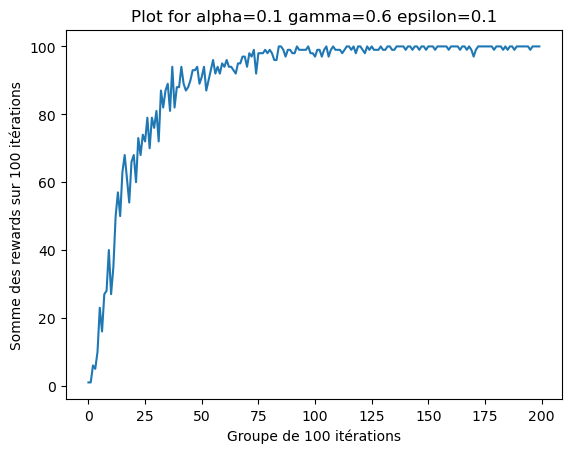

In [9]:
scores = test_hyperparams(DEFAULT_ALPHA, DEFAULT_GAMMA, DEFAULT_EPSILON)

In [13]:
def measure_hyperparams_score(epochs, epsilon, gamma):
    print("Testing : ",epochs, epsilon, gamma)

    q_table = np.zeros([env.observation_space.n, env.action_space.n])

    alpha = DEFAULT_ALPHA
    
    # training
    for i in range(1, epochs + 1):
        state, _ = env.reset()

        epochs, reward, = 0, 0
        done = False
        
        while not done:
            q_table, state, reward, done = step_once(q_table, state, epsilon, alpha, gamma, learning=True)
            epochs += 1

    # measuring     
    score = 0
    for episode in range(N_EPISODES):
        state, _ = env.reset()
        reward = 0
        
        done = False
        epochs = 0
        while not done and epochs < MAX_EPOCHS_IN_EPISODE:
            q_table, state, reward, done = step_once(q_table, state, epsilon, alpha, gamma, learning=False)

            if reward == 20:
                score += 1
                break
            epochs += 1
    return score

In [14]:
# Recherche des meilleurs hyperparamètres
epochs = [5000,10000,15000,20000]
epsilons = [0.1, 0.2, 0.3, 0.4]
gammas = [0.4,0.6,0.9]

data = []
for e in epochs:
    for eps in epsilons:
        for g in gammas:
            print("Progress : ", len(data)," /",len(epochs)*len(epsilons)*len(gammas))

            score = measure_hyperparams_score(e, eps, g)
            data.append((score, e, eps, g))
            print("score :", score)

Progress :  0  / 48
Testing :  5000 0.1 0.4
score : 89
Progress :  1  / 48
Testing :  5000 0.1 0.6
score : 92
Progress :  2  / 48
Testing :  5000 0.1 0.9
score : 100
Progress :  3  / 48
Testing :  5000 0.2 0.4
score : 91
Progress :  4  / 48
Testing :  5000 0.2 0.6
score : 97
Progress :  5  / 48
Testing :  5000 0.2 0.9
score : 100
Progress :  6  / 48
Testing :  5000 0.3 0.4
score : 89
Progress :  7  / 48
Testing :  5000 0.3 0.6
score : 100
Progress :  8  / 48
Testing :  5000 0.3 0.9
score : 100
Progress :  9  / 48
Testing :  5000 0.4 0.4
score : 92
Progress :  10  / 48
Testing :  5000 0.4 0.6
score : 100
Progress :  11  / 48
Testing :  5000 0.4 0.9
score : 100
Progress :  12  / 48
Testing :  10000 0.1 0.4
score : 97
Progress :  13  / 48
Testing :  10000 0.1 0.6
score : 100
Progress :  14  / 48
Testing :  10000 0.1 0.9
score : 100
Progress :  15  / 48
Testing :  10000 0.2 0.4
score : 98
Progress :  16  / 48
Testing :  10000 0.2 0.6
score : 100
Progress :  17  / 48
Testing :  10000 0.2 0.

In [40]:
data_sorted = sorted(data, key=lambda x: x[0], reverse=True)
for score, e, eps, g in data_sorted[:50]:  # par exemple top 10
    print(f"Score: {score:.2f} | Epochs: {e} | Epsilon: {eps} | Gamma: {g}")

Score: 100.00 | Epochs: 5000 | Epsilon: 0.1 | Gamma: 0.9
Score: 100.00 | Epochs: 5000 | Epsilon: 0.2 | Gamma: 0.9
Score: 100.00 | Epochs: 5000 | Epsilon: 0.3 | Gamma: 0.6
Score: 100.00 | Epochs: 5000 | Epsilon: 0.3 | Gamma: 0.9
Score: 100.00 | Epochs: 5000 | Epsilon: 0.4 | Gamma: 0.6
Score: 100.00 | Epochs: 5000 | Epsilon: 0.4 | Gamma: 0.9
Score: 100.00 | Epochs: 10000 | Epsilon: 0.1 | Gamma: 0.6
Score: 100.00 | Epochs: 10000 | Epsilon: 0.1 | Gamma: 0.9
Score: 100.00 | Epochs: 10000 | Epsilon: 0.2 | Gamma: 0.6
Score: 100.00 | Epochs: 10000 | Epsilon: 0.2 | Gamma: 0.9
Score: 100.00 | Epochs: 10000 | Epsilon: 0.3 | Gamma: 0.4
Score: 100.00 | Epochs: 10000 | Epsilon: 0.3 | Gamma: 0.6
Score: 100.00 | Epochs: 10000 | Epsilon: 0.3 | Gamma: 0.9
Score: 100.00 | Epochs: 10000 | Epsilon: 0.4 | Gamma: 0.4
Score: 100.00 | Epochs: 10000 | Epsilon: 0.4 | Gamma: 0.6
Score: 100.00 | Epochs: 10000 | Epsilon: 0.4 | Gamma: 0.9
Score: 100.00 | Epochs: 15000 | Epsilon: 0.1 | Gamma: 0.4
Score: 100.00 | Epoc

In [15]:
print('Training the agent')

# Hyperparameters
alpha = DEFAULT_ALPHA
gamma = 0.6
epsilon = 0.3

# For plotting metrics
all_epochs = []
all_penalties = []

for i in range(1, 20001):
    state, _ = env.reset()

    epochs, penalties, reward, = 0, 0, 0
    done = False
    
    while not done:
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()        # Explore action space
        else:
            action = argmax_choice(q_table[state,:])  # Exploit learned values

        next_state, reward, done, _, _ = env.step(action) 
        
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state,:])
        
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value

        if reward == -10:
            penalties += 1

        state = next_state
        epochs += 1
        
    if i % 100 == 0:
        clear_output(wait=True)
        print(f'Episode: {i}')

print('Training finished.\n')
print(f'Penalties: {penalties}')

Episode: 20000
Training finished.

Penalties: 4


## Visualizing the Q table after learning

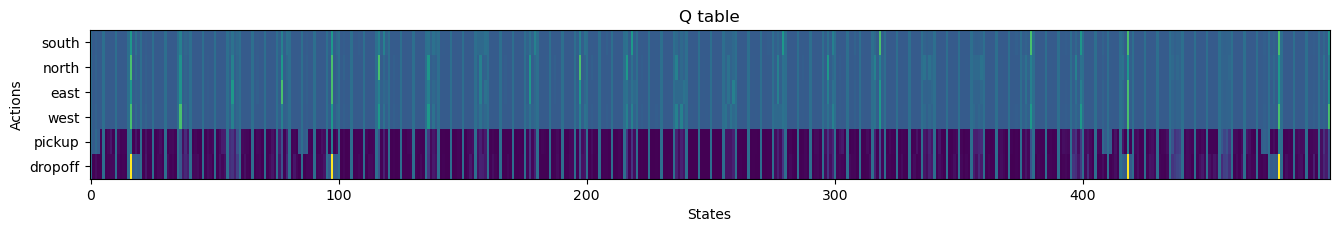

In [16]:
show_q_table(q_table)

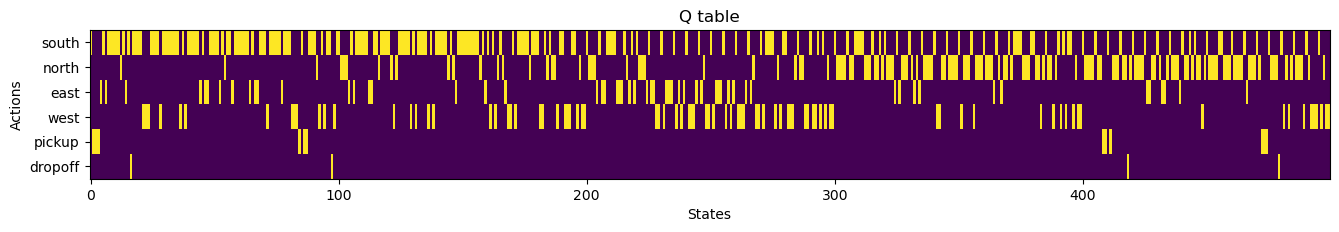

In [17]:
show_q_table(q_table, binary=True)

In [18]:
dropoff_states = [i for i in range(len(q_table)) if np.argmax(q_table[i]) == 5]
print(f'List of states where the agent has to drop off the passenger: {dropoff_states}')

pickup_states = [i for i in range(len(q_table)) if np.argmax(q_table[i]) == 4]
print(f'List of states where the agent has to pick up the passenger: {pickup_states}')

List of states where the agent has to drop off the passenger: [16, 97, 418, 479]
List of states where the agent has to pick up the passenger: [1, 2, 3, 84, 86, 87, 408, 409, 411, 472, 473, 474]


## Evaluate agent's performance after Q-learning

In [19]:
total_epochs, total_penalties, total_fails = 0, 0, 0
episodes = 100
max_epochs = 100

for _ in range(episodes):
    state, _ = env.reset()
    epochs, penalties, reward = 0, 0, 0
    
    done = False
    
    while not done and epochs < max_epochs:
        action = argmax_choice(q_table[state,:])
        state, reward, done, _, _ = env.step(action)

        if reward == -10:
            penalties += 1

        epochs += 1
    
    if epochs == max_epochs:
        total_fails += 1
    total_penalties += penalties
    total_epochs += epochs

print(f'Results after {episodes} episodes:')
print(f'Average timesteps per episode: {total_epochs / episodes}')
print(f'Average penalties per episode: {total_penalties / episodes}')
print(f'Number of fails: {total_fails}')

Results after 100 episodes:
Average timesteps per episode: 12.56
Average penalties per episode: 0.0
Number of fails: 0


## Visualizing an individual episode

In [20]:
state, _ = env.reset()
epochs, penalties, reward = 0, 0, 0

done = False

while not done:
    action = argmax_choice(q_table[state,:])
    state, reward, done, _, _ = env.step(action)

    if reward == -10:
        penalties += 1

    epochs += 1
    
    clear_output(wait=True)
    print(env.render())
    sleep(.2)

print(f'Timesteps: {epochs}')
print(f'Penalties: {penalties}')

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Timesteps: 12
Penalties: 0


## Analysis
Examine the behaviour of the agent for dropoff and pickup.

The following function decodes the state code [0, 500]

In [21]:
def decode_state(s):
    items = ['taxi row', 'taxi col', 'passenger location', 'destination']
    positions = ['R', 'G', 'Y', 'B', 'T']
    for i,j in enumerate(env.decode(s)):
        if i > 1:
            print(items[i], ':', positions[j])
        else:
            print(items[i], ':', j)

decode_state(120)

taxi row : 1
taxi col : 1
passenger location : R
destination : R


Knowing the code of each action

    0: move south
    1: move north
    2: move east
    3: move west
    4: pickup passenger
    5: drop off passenger

The states in which the agent decides to perform the action 'dropoff' can be computed as:

In [22]:
dropoff = np.where(np.argmax(q_table, axis=1) == 5)[0]

## Simulation avec plusieurs passagers

In [34]:
MAX_STEPS = 200

def run_one_simulation(env, q_table):
    """
    Simule une mission complète : récupérer 3 passagers aux emplacements 1, 2, 3
    et les déposer à l'emplacement 0.
    """
    total_steps = 0
    success = True
    
    passengers = [1, 2, 3]
    destination = 0
    
    for passenger_loc in passengers:
        env.reset()
        state = env.encode(0, 0, passenger_loc, destination)
        env.s = state
        
        done = False
        steps = 0
        
        while not done and steps < MAX_STEPS:
            action = np.argmax(q_table[state])
            state, reward, done, _, _ = env.step(action)
            steps += 1
            total_steps += 1
        
        if not done or reward < 20:  # Taxi-v3 donne +20 de reward si le dropoff est réussi
            success = False
            break  # Stop si un passager est mal déposé
        
    return success, total_steps

env = gym.make("Taxi-v3")

n_simulations = 100
results = [run_one_simulation(env, q_table) for _ in range(n_simulations)]

# résultats
success_count = sum(1 for success, _ in results if success)
average_steps = np.mean([steps for _, steps in results])

print(f"Pourcentage de succès: {success_count / n_simulations * 100:.2f}%")
print(f"Nombre moyen d'étapes: {average_steps:.2f}")

Pourcentage de succès: 96.00%
Nombre moyen d'étapes: 49.06


### Decode all the states in which the agent decides to perform the action 'dropoff' and analyse if the rules the agent learnt seem correct

In [ ]:
dropoff_states = [state for state in range(len(q_table)) if np.argmax(q_table[state]) == 5]

print(f"Nombre de states où l'action choisie est 'dropoff' : {len(dropoff_states)}")
for state in dropoff_states:
    taxi_row, taxi_col, passenger_location, destination = env.decode(state)
    print(f"State {state}: Taxi at ({taxi_row},{taxi_col}), passenger_location={passenger_location}, destination={destination}")


Nombre de states où l'action choisie est 'dropoff' : 4
State 16: Taxi at (0,0), passenger_location=4, destination=0
State 97: Taxi at (0,4), passenger_location=4, destination=1
State 418: Taxi at (4,0), passenger_location=4, destination=2
State 479: Taxi at (4,3), passenger_location=4, destination=3


### Decode all the states in which the agent decides to perform the action 'pickup' and analyse if the rules the agent learnt seem correct

In [36]:
pickup_states = [state for state in range(len(q_table)) if np.argmax(q_table[state]) == 4]

print(f"Nombre de states où l'action choisie est 'pickup' : {len(pickup_states)}")
for state in pickup_states:
    taxi_row, taxi_col, passenger_location, destination = env.decode(state)
    print(f"State {state}: Taxi at ({taxi_row},{taxi_col}), passenger_location={passenger_location}, destination={destination}")


Nombre de states où l'action choisie est 'pickup' : 12
State 1: Taxi at (0,0), passenger_location=0, destination=1
State 2: Taxi at (0,0), passenger_location=0, destination=2
State 3: Taxi at (0,0), passenger_location=0, destination=3
State 84: Taxi at (0,4), passenger_location=1, destination=0
State 86: Taxi at (0,4), passenger_location=1, destination=2
State 87: Taxi at (0,4), passenger_location=1, destination=3
State 408: Taxi at (4,0), passenger_location=2, destination=0
State 409: Taxi at (4,0), passenger_location=2, destination=1
State 411: Taxi at (4,0), passenger_location=2, destination=3
State 472: Taxi at (4,3), passenger_location=3, destination=0
State 473: Taxi at (4,3), passenger_location=3, destination=1
State 474: Taxi at (4,3), passenger_location=3, destination=2


*Vérification et explication des règles :*

Les règles pour le dropoff semblent bonnes. Le taxi pose les passagers quand sa position est égale à la position de destination du passager. Ici, c'est simple, on dropoff si la position du taxi est égal à la destination du passager, il n'y a donc que 4 possibilités (vu qu'il y a 4 destinations possible).

Pour le pickup, c'est un peu plus compliqué, car il y a plus d'états distincts. Pour être exact, il y a 4 emplacements de départ possible et 3 emplacements de destination possible pour chaque emplacement de départ (4-1 car un passager ne peut pas aller au même endroit qu'il est actuellement), donc 4*3 = 12 états possibles. Ces règles sont également correctes.


